## This section is a backlog of things I did earlier in the pipeline, part of the iterative process
1. Generate the first iteration of the db that was put into Logan (PVDB1)
    * intermediate files and products
2. HMM generation
    * download PAVE sequences, generate first version of the L1 hmms
    * updating this HMM with the NCBI L1 sequences
    * another iteration with the novel sequences from the first iteration

In [2]:
%load_ext rpy2.ipython
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
#misc setup, honestly idk if i need these but it worked last time.

In [ ]:
%%bash
#Using all nucleotide sequences on NCBI as of 2024.06.18 taxid: 151340, downloaded through ncbi virus online portal
#get sto-sto orfs
getorf -sequence 2024.06.18.PV_nucs -outseq PV_nucs_getorf.fa -find 0 -nomethionine

#use pfam models to annotate
hmmsearch --F1 0.01 -T 20 --domtblout updated_PV_nucs.domtbl "/home/rnalab/js/HPV_project/PVfam_full" PV_nucs_getorf.fa

#convert to one line format
#(this is when i didnt know about fx2tab)
seqtk/seqtk seq PV_nucs_getorf.fa > PV_nucs_getorf_1line.fa

#grep actual hits
grep -A 1 -F -f pv_2_hmmer_hits.txt PV_nucs_getorf_1line.fa | sed '/^--/d' > pv_2_hmmer_orfs.fa

#header parsing my worst enemy
#(this is when i was bad at sed, still am, but less bad)
sed -i.bak 's/|.*|//' pv_2_hmmer_orfs.fa
sed -i.bak 's/\[.*\]//' pv_2_hmmer_orfs.fa
perl -lpe   'BEGIN { %id_to_function = map { /^(\S+)\s+(.*)/ } `cat hmmer_key_pv2.txt`; } s{^>(\S+)(.*)}{>$1$2 $id_to_function{$1}};' pv_2_hmmer_orfs.fa > pv_2_orfs_info.fa
sed -i.bak 's/NC_/NC+/g' pv_2_orfs_info.fa
sed -i.bak 's/ /\./' pv_2_orfs_info.fa

sed -i.bak 's/ \([^ ]*\)$/.\1/' pv_2_orfs_info.fa
sed -i.bak 's/ /_/g' pv_2_hmmer_orfs.fa
sed -i.bak 's/>/>papilloma./' pv_2_orfs_info.fa
awk 'BEGIN {FS="."; OFS="."} {print $1, $4, $3, $2}' pv_2_orfs_info.fa > pv_2_orfs_clean.fa
sed -i.bak 's/\.\.\.//' pv_2_orfs_clean.fa
sed 's/\.\([^\.]*\)$/:\1/' pv_2_orfs_clean > pv_2_orfs_clean_final.fa
sed -i.bak 's/NC+/NC_/g' pv_2_orfs_clean_final.fa

#prune things that have xxxx
#this is because some nucleotide entries on ncbi virus have NNN nucleotides :/
seqkit fx2tab pv_2_orfs_clean_final.fa | awk '! ( $2 ~ /X/)'  | seqkit tab2fx > pv_2_orfs_pruned.fa

#clustering at 90% identity , rename some dupes
seqkit rename pv_2_orfs_pruned.fa > pv_2_orfs_pruned_rn.fa
seqkit sort -l -r pv_2_orfs_pruned_rn.fa > pv_2_orfs_pruned_rn_sorted.fa

usearch --cluster_smallmem pv_2_orfs_pruned_rn_sorted.fa -id 0.90 -centroids pv_2_orfs_pruned_rn_sorted_centroids.fa -uc pv_2_orfs_pruned_rn_sorted_clusters.uc

#working file
pv_2_orfs_pruned_rn_sorted_centroids.fa

#using logan-unsticker, https://github.com/syueqiao/logan_unsticker, run against human genome, ecoli genome, yeast genome, mouse genome and bos tauros
#human
./logan_unsticker.sh -b "https://hgdownload.soe.ucsc.edu/goldenPath/hs1/bigZips/hs1.2bit" pv_2_orfs_pruned_rn_sorted_centroids.fa
#yeast
./logan_unsticker.sh -b "https://hgdownload.soe.ucsc.edu/goldenPath/sacCer3/bigZips/sacCer3.2bit" pv_2_orfs_pruned_rn_sorted_centroids.fa
#mouse
./logan_unsticker.sh "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz" pv_2_orfs_pruned_rn_sorted_centroids.fa
#ecoli
./logan_unsticker.sh "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz" pv_2_orfs_pruned_rn_sorted_centroids.fa

#format 2024.06.21.things_cleaned_bed_file to text file (manually)
"/home/rnalab/js/bedtools" maskfasta -fi pv_2_orfs_pruned_rn_sorted_centroids.fa -bed trim.txt -fo masked.fasta -mc +
 sed -i.bak 's/+//g' masked.fasta

#re-run
#human
./logan_unsticker.sh -b "https://hgdownload.soe.ucsc.edu/goldenPath/hs1/bigZips/hs1.2bit" masked.fasta
#yeast
./logan_unsticker.sh -b "https://hgdownload.soe.ucsc.edu/goldenPath/sacCer3/bigZips/sacCer3.2bit" masked.fasta
#mouse
./logan_unsticker.sh "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz" masked.fasta
#ecoli
./logan_unsticker.sh "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz" masked.fasta

#now when run against the 4 QC genomes, only hits that come up are low confidence (> e*10^-4)
#run this database against the 3400 test set that Rayan has generated, results at: s3://serratus-rayan/beetles/logan_july1_run/diamond

In [4]:
%%R
library(tidyverse)
#visualize and look for summary stats
july_3400_test <- read.table("july1_3400_run.pro", sep = "\t", fill = T)
eval_fil_july_3400_test <- filter(july_3400_test, V11 < 0.000000001 )
jul1_test <- eval_fil_july_3400_test
july_3400_test <- read.table("july1_3400_run.pro", sep = "\t", fill = T)

#filter for pv only
pv2_test <- filter(jul1_test, grepl("papilloma", V6))
#get clean acc
pv2_test$V14 <- sub("_.*", "", pv2_test$V1)

#get e score and choose "lowest"
pv2_test$e_score <- -log10(pv2_test$V11)

pv2_test_sliced <- pv2_test %>% group_by(V1) %>% slice_max(order_by = e_score, n = 1)
pv2_test_sliced <- pv2_test_sliced %>% group_by(V1) %>% slice_max(order_by = V10, n = 1)


pv2_test_sliced$q_cov <- abs(pv2_test_sliced$V2 - pv2_test_sliced$V3)/pv2_test_sliced$V4
pv2_test_sliced$m_cov <- abs(pv2_test_sliced$V7 - pv2_test_sliced$V8)/pv2_test_sliced$V9
pv2_test_sliced$m_cov_aa <- abs(pv2_test_sliced$V7 - pv2_test_sliced$V8)
#visualizations follow, investigate shape of data

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


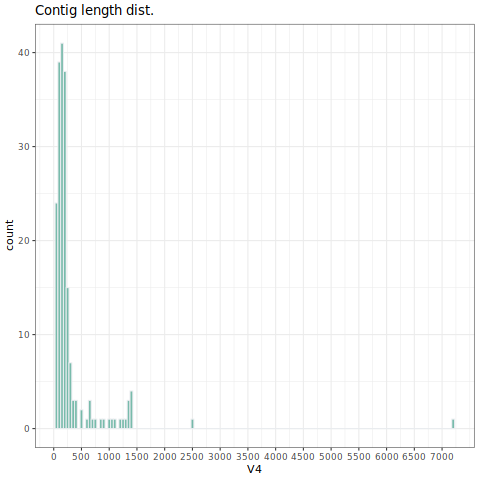

In [5]:
%%R
ggplot(pv2_test_sliced, aes(x=V4)) +
  geom_histogram(, binwidth = 50, fill="#69b3a2", color="#e9ecef", alpha=0.9) +
  theme_bw() +
  ggtitle("Contig length dist.") +
  scale_x_continuous(breaks = round(seq(min(0), max(pv2_test_sliced$V4), by = 500),1))

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: Removed 2 rows containing non-finite values (`stat_bin()`). 



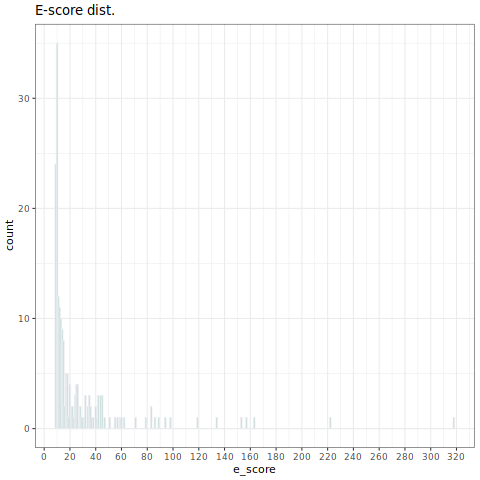

In [6]:
%%R
ggplot(pv2_test_sliced, aes(x=e_score)) +
  geom_histogram(, binwidth = 1, fill="#69b3a2", color="#e9ecef", alpha=0.9) +
  theme_bw() +
  ggtitle("E-score dist.") +
  scale_x_continuous(breaks = round(seq(min(0), max(350), by = 20),1))

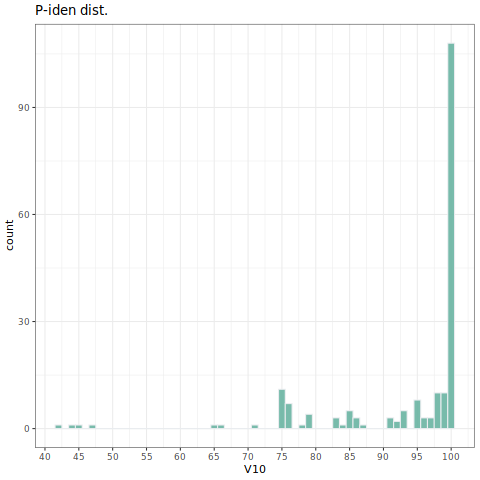

In [7]:
%%R
ggplot(pv2_test_sliced, aes(x=V10)) +
  geom_histogram(, binwidth = 1, fill="#69b3a2", color="#e9ecef", alpha=0.9) +
  theme_bw() +
  ggtitle("P-iden dist.") +
  scale_x_continuous(breaks = round(seq(min(0), max(100), by = 5),1))


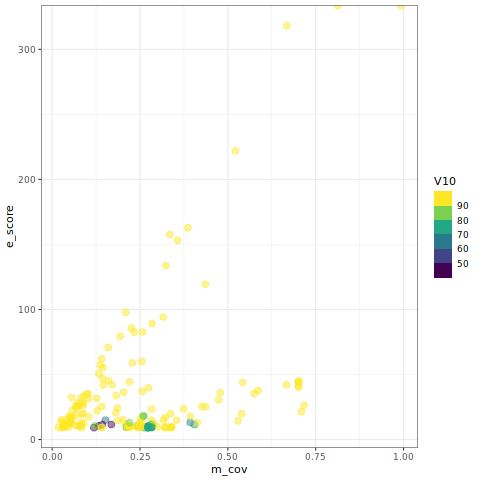

In [7]:
%%R
ggplot(pv2_test_sliced, aes(x=m_cov, y=e_score, colour = V10)) +
  geom_point(size = 3, alpha = 0.5) +
  theme_bw() +
  scale_color_viridis_b(option = "D")


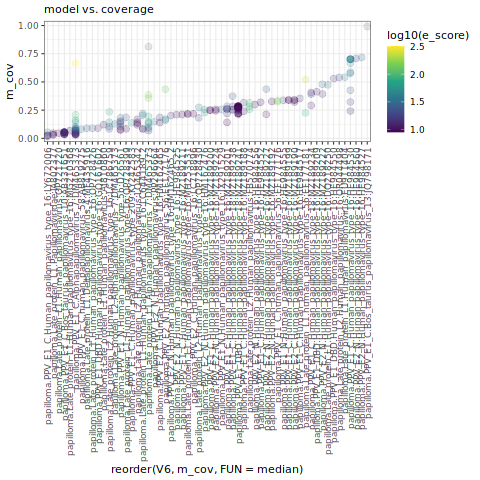

In [8]:
%%R
pv2_test_sliced %>%
  ggplot(aes(x=reorder(V6, m_cov, FUN = median), y=m_cov, color=log10(e_score))) +
  geom_point(size = 3, alpha = 0.2) +
  scale_color_viridis_c() +
  # geom_jitter(color="black", size=0.4, alpha=0.9) +
  theme_bw() +
  theme(
    plot.title = element_text(size=11)
  ) +
  ggtitle("model vs. coverage") + 
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

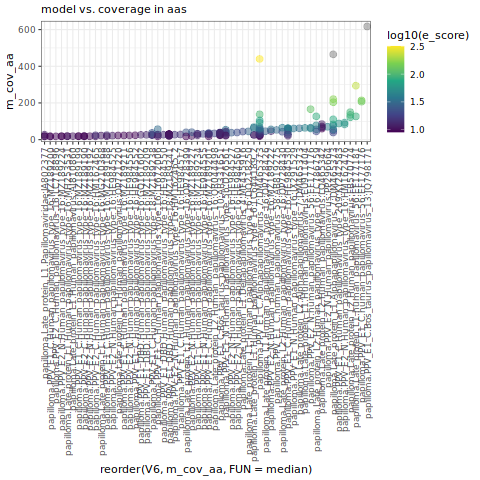

In [9]:
%%R
pv2_test_sliced %>%
  ggplot(aes(x=reorder(V6, m_cov_aa, FUN = median), y=m_cov_aa, color=log10(e_score))) +
  geom_point(size = 3, alpha = 0.5) +
  scale_color_viridis_c() +
  # geom_jitter(color="black", size=0.4, alpha=0.9) +
  theme_bw() +
  theme(
    plot.title = element_text(size=11)
  ) +
  ggtitle("model vs. coverage in aas") + 
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# pv2_test_sliced_AB331651 <- filter(pv2_test_sliced, V6 == "papilloma.PPV_E1_C.Bos_taurus_papillomavirus_10:AB331651")
# write.table(pv2_test_sliced_AB331651$V1, "pv2_test_sliced_AB331651.txt", row.names = F, col.names = F)

# pv2_test_sliced_MZ189241 <- filter(pv2_test_sliced, V6 == "papilloma.PPV_E1_DBD.Human_papillomavirus_type_18:MZ189241")
# write.table(pv2_test_sliced_MZ189241$V1, "pv2_test_sliced_MZ189241", row.names = F, col.names = F)

# write.table(paste0(pv2_test_sliced$V14, collapse = ","), "pv2_test_sliced_SRA.txt", row.names = F, col.names = F, quote = F, sep = ",")
# names(pv2_test_sliced)[names(pv2_test_sliced) == 'V14'] <- 'Run'

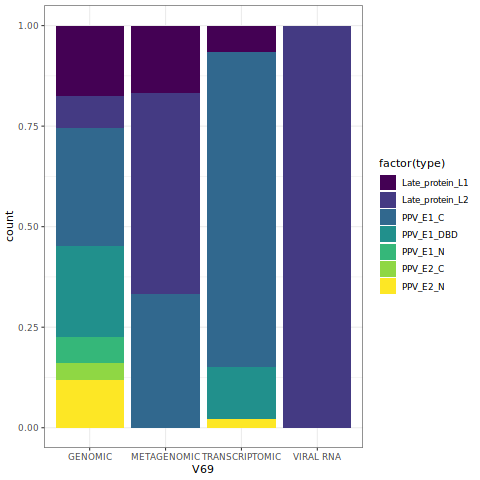

In [13]:
%%R
sra_metadata <- read.table("3400_sra_metadata.txt", sep = ",", fill = T, header = T)
pv2_test_sliced_metadata <- left_join(pv2_test_sliced, sra_metadata, by = c("V14" = "Run"))
pv2_test_sliced_metadata <- pv2_test_sliced_metadata[,1:33]

pv2_test_sliced_metadata$type <- sub("[^.]+\\.([^.]+)\\..*", "\\1", pv2_test_sliced_metadata$V6)


pv2_test_sliced_metadata$type_grouped <-gsub("_N","",as.character(pv2_test_sliced_metadata$type))
pv2_test_sliced_metadata$type_grouped <-gsub("_C","",as.character(pv2_test_sliced_metadata$type_grouped))
pv2_test_sliced_metadata$type_grouped <-gsub("_DBD","",as.character(pv2_test_sliced_metadata$type_grouped))
pv2_test_sliced_metadata$V69 <- pv2_test_sliced_metadata$LibrarySource

#normalized proportion bar
ggplot(pv2_test_sliced_metadata, aes(fill=factor(type), x=V69)) + 
  geom_bar(position = "fill") +
  scale_fill_viridis_d() +
  theme_bw()

In [ ]:
%%R
##these look slihglty problematic
pv2_test_sliced_AB331651 <- filter(pv2_test_sliced, V6 == "papilloma.PPV_E1_C.Bos_taurus_papillomavirus_10:AB331651")

pv2_test_sliced_MZ189241 <- filter(pv2_test_sliced, V6 == "papilloma.PPV_E1_DBD.Human_papillomavirus_type_18:MZ189241")
#removed manually from masked.fasta, see tracking sheet (things_cleaned - reflected in there)

## final version input into logan run 1: pv3.fa (masked.fasta)

    * run once again against 3400 accession:  s3://serratus-rayan/beetles/logan_july5_run/diamond/ - no changes made as a result of this
    * full logan run: s3://serratus-rayan/beetles/logan_july5_run/diamond-concat/all_diamond.2.txt.zst

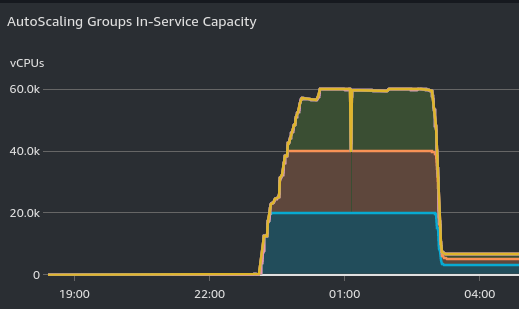